In [1]:
import tensorflow as tf
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

GPU: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Cek apakah HAM1000 bisa diakses
paths = [
    '/content/drive/My Drive/Data Projek Big Data/HAM1000',
    '/content/drive/MyDrive/Data Projek Big Data/HAM1000',
    '/content/drive/Shareddrives/Data Projek Big Data/HAM1000'
]

for p in paths:
    if os.path.exists(p):
        print(f"FOUND: {p}")
        for folder in sorted(os.listdir(p)):
            fp = os.path.join(p, folder)
            if os.path.isdir(fp):
                count = len(os.listdir(fp))
                print(f"  {folder}: {count}")
        break
else:
    print("Tidak ditemukan! Cek isi drive:")
    base = '/content/drive/My Drive/Data Projek Big Data/'
    if os.path.exists(base):
        for f in os.listdir(base):
            print(f"  {f}")

FOUND: /content/drive/My Drive/Data Projek Big Data/HAM1000
  Actinic_Keratosis: 327
  Basal_Cell_Carcinoma: 514
  Benign_Keratosis: 1099
  Dermatofibroma: 115
  Melanocytic_Nevi: 6705
  Melanoma: 1113
  Vascular_Lesion: 142


# SETUP LENGKAP - SPLIT, GENERATOR, CLASS WEIGHTS

In [4]:
import pandas as np
import tensorflow as tf
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ============================================
# CELL 2: SETUP LENGKAP - SPLIT, GENERATOR, CLASS WEIGHTS
# ============================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7
DATA_DIR = '/content/drive/My Drive/Data Projek Big Data/HAM1000'

# ============================================
# SPLIT: 70% train, 15% val, 15% test
# ============================================
full_datagen = ImageDataGenerator(validation_split=0.3)
temp_gen = full_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, class_mode='categorical',
    subset='validation', shuffle=False
)
class_names = list(temp_gen.class_indices.keys())
print("Classes:", class_names)

# ============================================
# GENERATOR UNTUK DENSENET201
# ============================================
dense_train_datagen = ImageDataGenerator(
    preprocessing_function=dense_preprocess,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.3
)

dense_val_datagen = ImageDataGenerator(
    preprocessing_function=dense_preprocess,
    validation_split=0.3
)

dense_train_gen = dense_train_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True, seed=42
)

dense_val_gen = dense_val_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

# ============================================
# GENERATOR UNTUK MOBILENETV2 (rescale 1/255)
# ============================================
mobile_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.3
)

mobile_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

mobile_train_gen = mobile_train_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True, seed=42
)

mobile_val_gen = mobile_val_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

# ============================================
# CLASS WEIGHTS (handle imbalance)
# ============================================
classes = np.unique(dense_train_gen.classes)
cw = compute_class_weight('balanced', classes=classes, y=dense_train_gen.classes)
class_weights = dict(enumerate(cw))

print(f"\nTrain: {dense_train_gen.samples}")
print(f"Val: {dense_val_gen.samples}")
print(f"\nClass weights:")
for k, v in class_weights.items():
    print(f"  {class_names[k]}: {v:.2f}")
print("\nAll generators ready!")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Done!")

GPU: True
Found 3001 images belonging to 7 classes.
Classes: ['Actinic_Keratosis', 'Basal_Cell_Carcinoma', 'Benign_Keratosis', 'Dermatofibroma', 'Melanocytic_Nevi', 'Melanoma', 'Vascular_Lesion']
Found 7014 images belonging to 7 classes.
Found 3001 images belonging to 7 classes.
Found 7014 images belonging to 7 classes.
Found 3001 images belonging to 7 classes.

Train: 7014
Val: 3001

Class weights:
  Actinic_Keratosis: 4.38
  Basal_Cell_Carcinoma: 2.78
  Benign_Keratosis: 1.30
  Dermatofibroma: 12.37
  Melanocytic_Nevi: 0.21
  Melanoma: 1.28
  Vascular_Lesion: 10.02

All generators ready!
GPU: True
Done!


In [1]:
# COPY KE LOCAL
import shutil, os

src = '/content/drive/My Drive/Data Projek Big Data/HAM1000'
dst = '/content/HAM1000'

if not os.path.exists(dst):
    print("Copying...")
    shutil.copytree(src, dst)
    print("Done!")

# UPDATE DATA_DIR
DATA_DIR = '/content/HAM1000'
print(f"Data dir: {DATA_DIR}")

Copying...
Done!
Data dir: /content/HAM1000


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7
DATA_DIR = '/content/HAM1000'

# Generator DenseNet
dense_train_gen = ImageDataGenerator(
    preprocessing_function=dense_preprocess,
    rotation_range=30, zoom_range=0.2,
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, brightness_range=[0.8, 1.2],
    horizontal_flip=True, vertical_flip=True,
    fill_mode='nearest', validation_split=0.3
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True, seed=42
)

dense_val_gen = ImageDataGenerator(
    preprocessing_function=dense_preprocess,
    validation_split=0.3
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

# Class weights
classes = np.unique(dense_train_gen.classes)
cw = compute_class_weight('balanced', classes=classes, y=dense_train_gen.classes)
class_weights = dict(enumerate(cw))
class_names = list(dense_train_gen.class_indices.keys())

print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Train: {dense_train_gen.samples}, Val: {dense_val_gen.samples}")
print("Ready!")

Found 7014 images belonging to 7 classes.
Found 3001 images belonging to 7 classes.
GPU: True
Train: 7014, Val: 3001
Ready!


# MODEL 1 - DENSENET201

In [4]:
# ============================================
# CELL 3: MODEL 1 - DENSENET201
# ============================================
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Base model
base_dense = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_dense.trainable = False

x = base_dense.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model_dense = Model(inputs=base_dense.input, outputs=output)
model_dense.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

cb = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Phase 1: Train head
print("DenseNet201 Phase 1: Training head...")
h1 = model_dense.fit(
    dense_train_gen, validation_data=dense_val_gen,
    epochs=10, callbacks=cb,
    class_weight=class_weights, verbose=1
)

# Phase 2: Fine-tune
print("\nDenseNet201 Phase 2: Fine-tuning...")
base_dense.trainable = True
for layer in base_dense.layers[:-50]:
    layer.trainable = False

model_dense.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

h2 = model_dense.fit(
    dense_train_gen, validation_data=dense_val_gen,
    epochs=10, callbacks=cb,
    class_weight=class_weights, verbose=1
)
print("DenseNet201 - DONE!")

DenseNet201 Phase 1: Training head...
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.4893 - loss: 1.5765 - val_accuracy: 0.6138 - val_loss: 1.0418 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 176s 798ms/step - accuracy: 0.5838 - loss: 1.0958 - val_accuracy: 0.6108 - val_loss: 1.0576 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 168s 762ms/step - accuracy: 0.6126 - loss: 0.9667 - val_accuracy: 0.6801 - val_loss: 0.8703 - learning_rate: 0.0010
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 204s 772ms/step - accuracy: 0.6302 - loss: 0.9151 - val_accuracy: 0.6711 - val_loss: 0.9031 - learning_rate: 0.0010
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 171s 778ms/step - accuracy: 0.6473 - loss: 0.8382 - val_accuracy: 0.6831 - val_loss: 0.8819 - learning_rate: 0.0010
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 174s 790ms/step - accuracy: 0.6614 - loss: 0.7979 - val_accuracy: 0.6485 - val_loss: 0.9761 - learning_rate: 0.0010
Epoch 7/10
220/220 ━━━━━━━━━━

In [6]:
# Generator MobileNetV2
mobile_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, zoom_range=0.2,
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, brightness_range=[0.8, 1.2],
    horizontal_flip=True, vertical_flip=True,
    fill_mode='nearest', validation_split=0.3
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True, seed=42
)

mobile_val_gen = ImageDataGenerator(
    rescale=1./255, validation_split=0.3
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

print("MobileNetV2 generators ready!")

Found 7014 images belonging to 7 classes.
Found 3001 images belonging to 7 classes.
MobileNetV2 generators ready!


# MODEL 2 - MOBILENETV2

In [7]:
# ============================================
# CELL 4: MODEL 2 - MOBILENETV2
# ============================================
from tensorflow.keras.applications import MobileNetV2

# Base model
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mobile.trainable = False

x = base_mobile.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output_m = Dense(NUM_CLASSES, activation='softmax')(x)

model_mobile = Model(inputs=base_mobile.input, outputs=output_m)
model_mobile.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

cb = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Phase 1
print("MobileNetV2 Phase 1: Training head...")
hm1 = model_mobile.fit(
    mobile_train_gen, validation_data=mobile_val_gen,
    epochs=10, callbacks=cb,
    class_weight=class_weights, verbose=1
)

# Phase 2: Fine-tune
print("\nMobileNetV2 Phase 2: Fine-tuning...")
base_mobile.trainable = True
for layer in base_mobile.layers[:-30]:
    layer.trainable = False

model_mobile.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

hm2 = model_mobile.fit(
    mobile_train_gen, validation_data=mobile_val_gen,
    epochs=10, callbacks=cb,
    class_weight=class_weights, verbose=1
)
print("MobileNetV2 - DONE!")

MobileNetV2 Phase 1: Training head...
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 210s 862ms/step - accuracy: 0.3935 - loss: 2.1250 - val_accuracy: 0.5448 - val_loss: 1.2070 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 722ms/step - accuracy: 0.4735 - loss: 1.5602 - val_accuracy: 0.5022 - val_loss: 1.3247 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 160s 728ms/step - accuracy: 0.4963 - loss: 1.3893 - val_accuracy: 0.5621 - val_loss: 1.2011 - learning_rate: 0.0010
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 161s 731ms/step - accuracy: 0.5154 - loss: 1.2953 - val_accuracy: 0.5255 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 158s 720ms/step - accuracy: 0.5190 - loss: 1.2006 - val_accuracy: 0.6198 - val_loss: 1.0732 - learning_rate: 0.0010
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 724ms/step - accuracy: 0.5344 - loss: 1.1778 - val_accuracy: 0.5728 - val_loss: 1.1551 - learning_rate: 0.0010
Epoch 7/10
220/220 ━━━━━━━

#  EVALUASI MODEL PADA DATA TEST

In [8]:
# ============================================
# CELL 7: EVALUASI MODEL PADA DATA TEST
# ============================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

class_names = list(dense_train_gen.class_indices.keys())

# Test generator DenseNet
dense_test_gen = ImageDataGenerator(
    preprocessing_function=dense_preprocess
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

# Test generator MobileNet
mobile_test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

# Predict
dense_pred = model_dense.predict(dense_test_gen, verbose=1)
mobile_pred = model_mobile.predict(mobile_test_gen, verbose=1)

y_true = dense_test_gen.classes
y_dense = np.argmax(dense_pred, axis=1)
y_mobile = np.argmax(mobile_pred, axis=1)

acc_dense = accuracy_score(y_true, y_dense)
acc_mobile = accuracy_score(y_true, y_mobile)

print("\n" + "="*50)
print("TEST ACCURACY")
print("="*50)
print(f"DenseNet201:  {acc_dense*100:.2f}%")
print(f"MobileNetV2:  {acc_mobile*100:.2f}%")
print("="*50)

print("\n=== DenseNet201 Classification Report ===")
print(classification_report(y_true, y_dense, target_names=class_names))

print("\n=== MobileNetV2 Classification Report ===")
print(classification_report(y_true, y_mobile, target_names=class_names))
print("Done!")

Found 10015 images belonging to 7 classes.
Found 10015 images belonging to 7 classes.
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 380ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 275ms/step

TEST ACCURACY
DenseNet201:  66.99%
MobileNetV2:  70.18%

=== DenseNet201 Classification Report ===
                      precision    recall  f1-score   support

   Actinic_Keratosis       0.53      0.42      0.47       327
Basal_Cell_Carcinoma       0.66      0.58      0.62       514
    Benign_Keratosis       0.41      0.79      0.54      1099
      Dermatofibroma       0.49      0.68      0.57       115
    Melanocytic_Nevi       0.98      0.65      0.78      6705
            Melanoma       0.34      0.75      0.47      1113
     Vascular_Lesion       0.78      0.91      0.84       142

            accuracy                           0.67     10015
           macro avg       0.60      0.68      0.61     10015
        weighted avg       0.81      0.67      0.70     10015


=== MobileNetV2 Classification Report =

# CONFUSION MATRIX

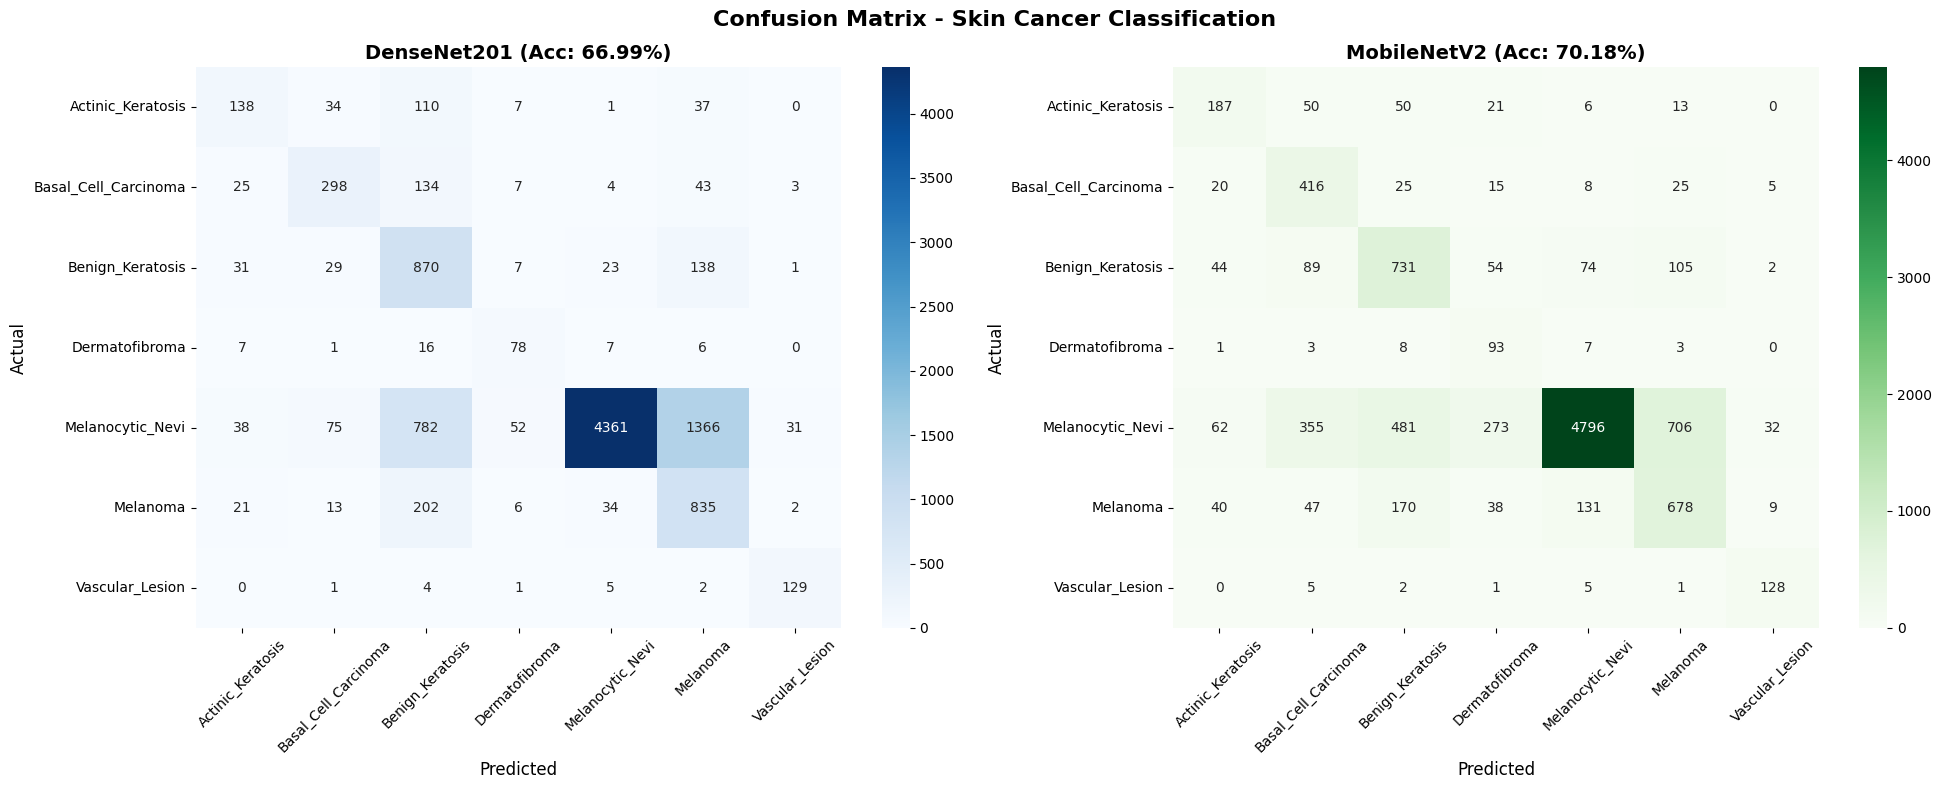

Saved!


In [9]:
# ============================================
# CELL 8: CONFUSION MATRIX
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# DenseNet201
cm_dense = confusion_matrix(y_true, y_dense)
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'DenseNet201 (Acc: {acc_dense*100:.2f}%)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# MobileNetV2
cm_mobile = confusion_matrix(y_true, y_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'MobileNetV2 (Acc: {acc_mobile*100:.2f}%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix - Skin Cancer Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data Projek Big Data/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved!")

#  ROC CURVE

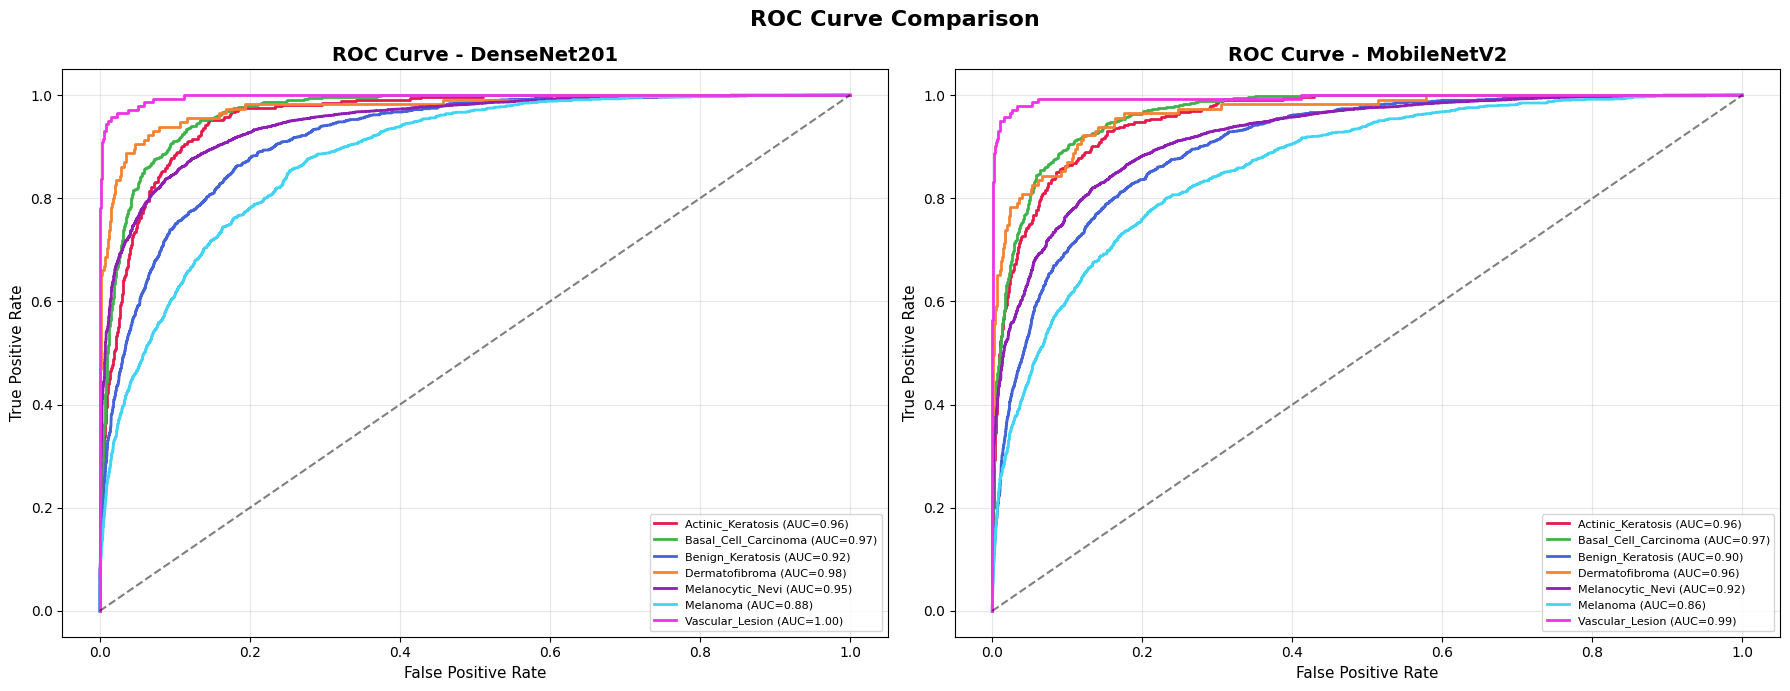

Saved!


In [10]:
# ============================================
# CELL 9: ROC CURVE
# ============================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, pred, title in zip(axes, [dense_pred, mobile_pred], ['DenseNet201', 'MobileNetV2']):
    for i, (name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.2f})')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5)
    ax.set_title(f'ROC Curve - {title}', fontweight='bold', fontsize=14)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data Projek Big Data/roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved!")

 # PERBANDINGAN MODEL

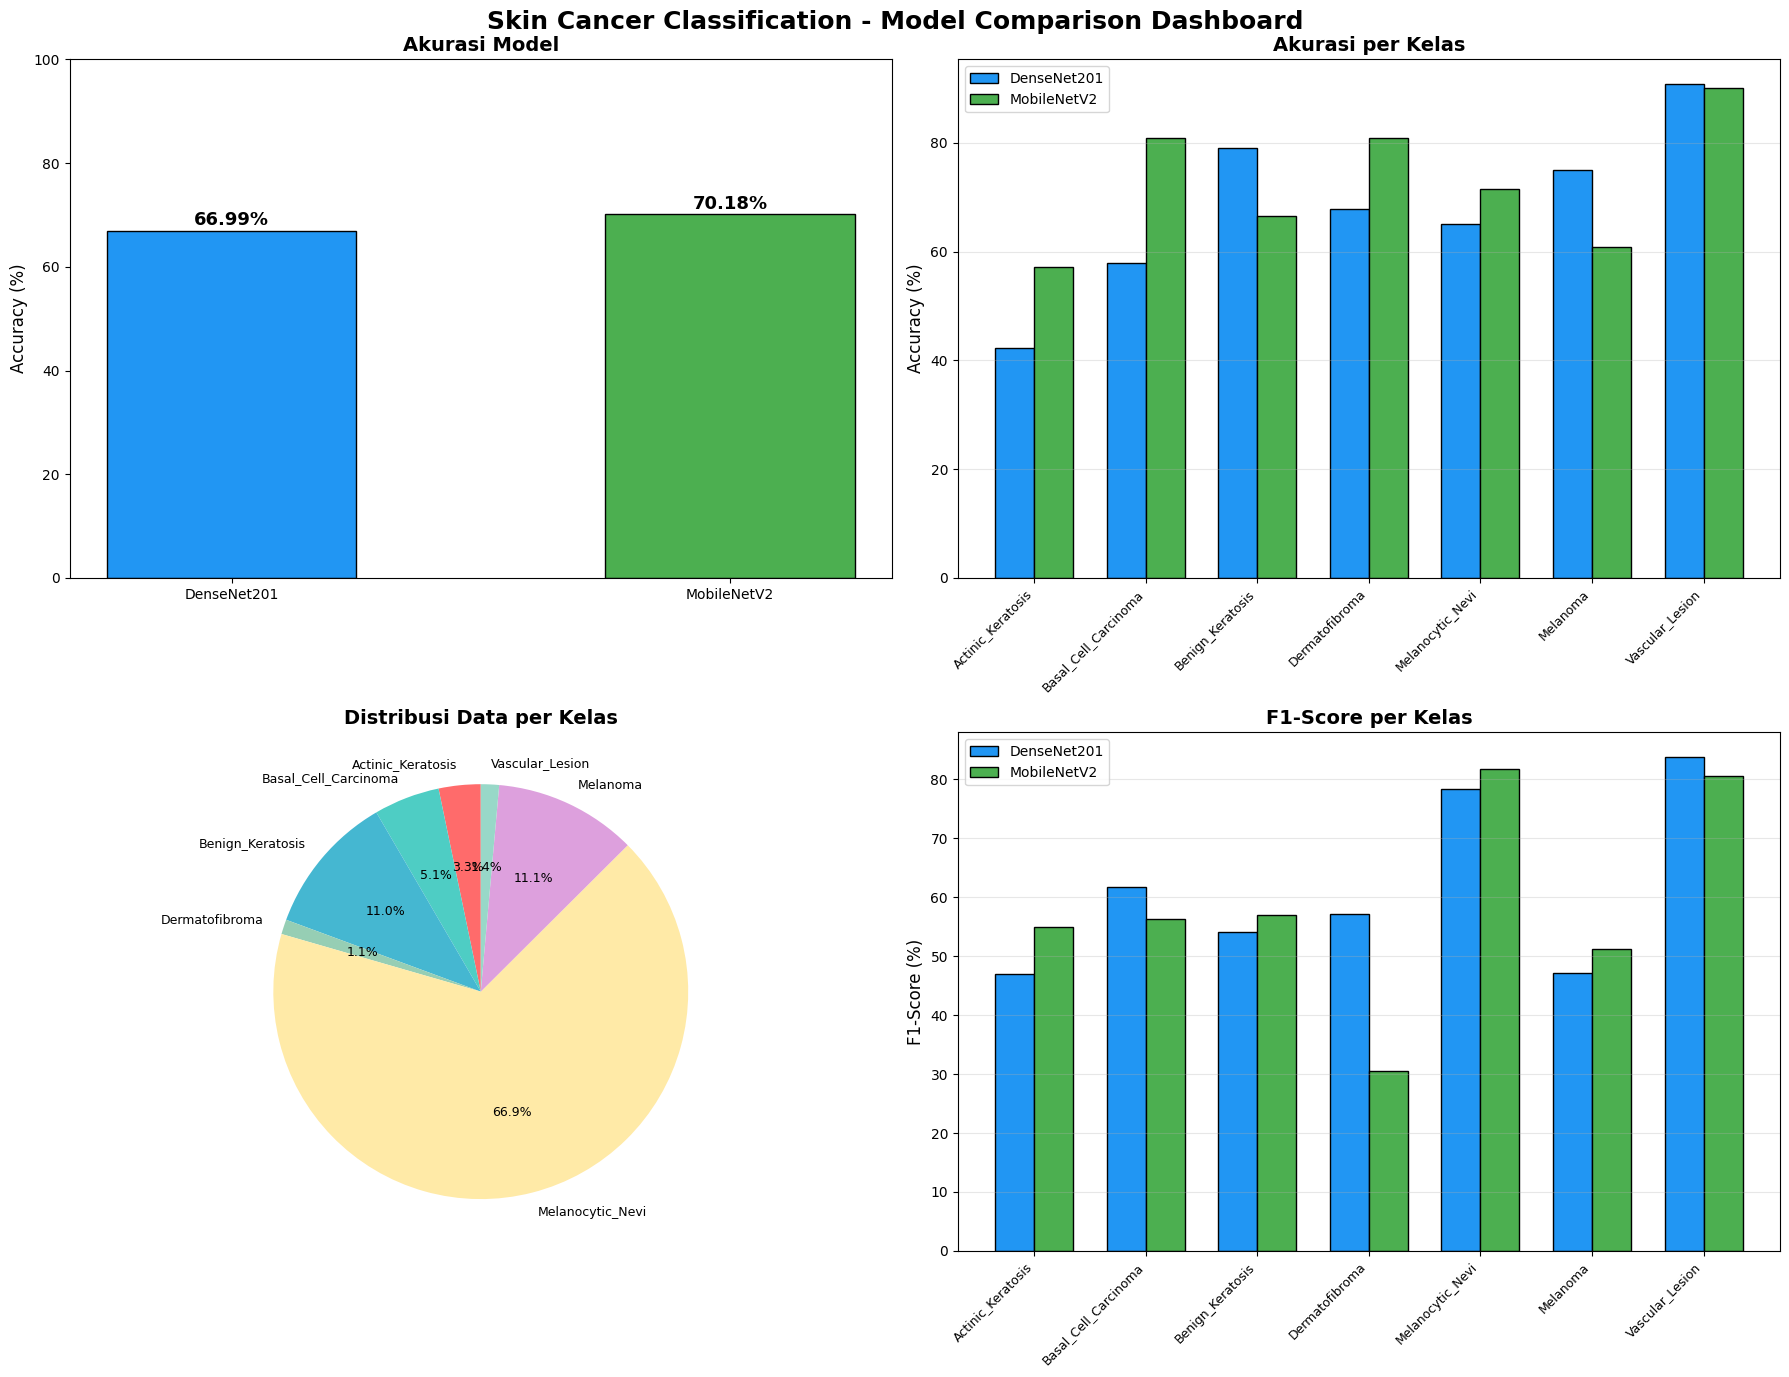

Saved!


In [11]:
# ============================================
# CELL 10: PERBANDINGAN MODEL
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Accuracy Comparison
models = ['DenseNet201', 'MobileNetV2']
accs = [acc_dense*100, acc_mobile*100]
colors_bar = ['#2196F3', '#4CAF50']
bars = axes[0,0].bar(models, accs, color=colors_bar, edgecolor='black', width=0.5)
axes[0,0].set_title('Akurasi Model', fontweight='bold', fontsize=14)
axes[0,0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0,0].set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)

# 2. Per-class Accuracy
dense_per = cm_dense.diagonal() / cm_dense.sum(axis=1) * 100
mobile_per = cm_mobile.diagonal() / cm_mobile.sum(axis=1) * 100
x_pos = np.arange(len(class_names))
w = 0.35
axes[0,1].bar(x_pos - w/2, dense_per, w, label='DenseNet201', color='#2196F3', edgecolor='black')
axes[0,1].bar(x_pos + w/2, mobile_per, w, label='MobileNetV2', color='#4CAF50', edgecolor='black')
axes[0,1].set_title('Akurasi per Kelas', fontweight='bold', fontsize=14)
axes[0,1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[0,1].legend(fontsize=10)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Distribusi Data
dist = [len([f for f in os.listdir(os.path.join(DATA_DIR, c)) if f.endswith('.jpg')]) for c in class_names]
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
axes[1,0].pie(dist, labels=class_names, autopct='%1.1f%%', colors=colors_pie,
              startangle=90, textprops={'fontsize': 9})
axes[1,0].set_title('Distribusi Data per Kelas', fontweight='bold', fontsize=14)

# 4. F1-Score Comparison
from sklearn.metrics import f1_score
f1_dense = f1_score(y_true, y_dense, average=None)
f1_mobile = f1_score(y_true, y_mobile, average=None)
axes[1,1].bar(x_pos - w/2, f1_dense*100, w, label='DenseNet201', color='#2196F3', edgecolor='black')
axes[1,1].bar(x_pos + w/2, f1_mobile*100, w, label='MobileNetV2', color='#4CAF50', edgecolor='black')
axes[1,1].set_title('F1-Score per Kelas', fontweight='bold', fontsize=14)
axes[1,1].set_ylabel('F1-Score (%)', fontsize=12)
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[1,1].legend(fontsize=10)
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Skin Cancer Classification - Model Comparison Dashboard', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data Projek Big Data/model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved!")

#  VISUALISASI PREDIKSI PADA GAMBAR ASLI

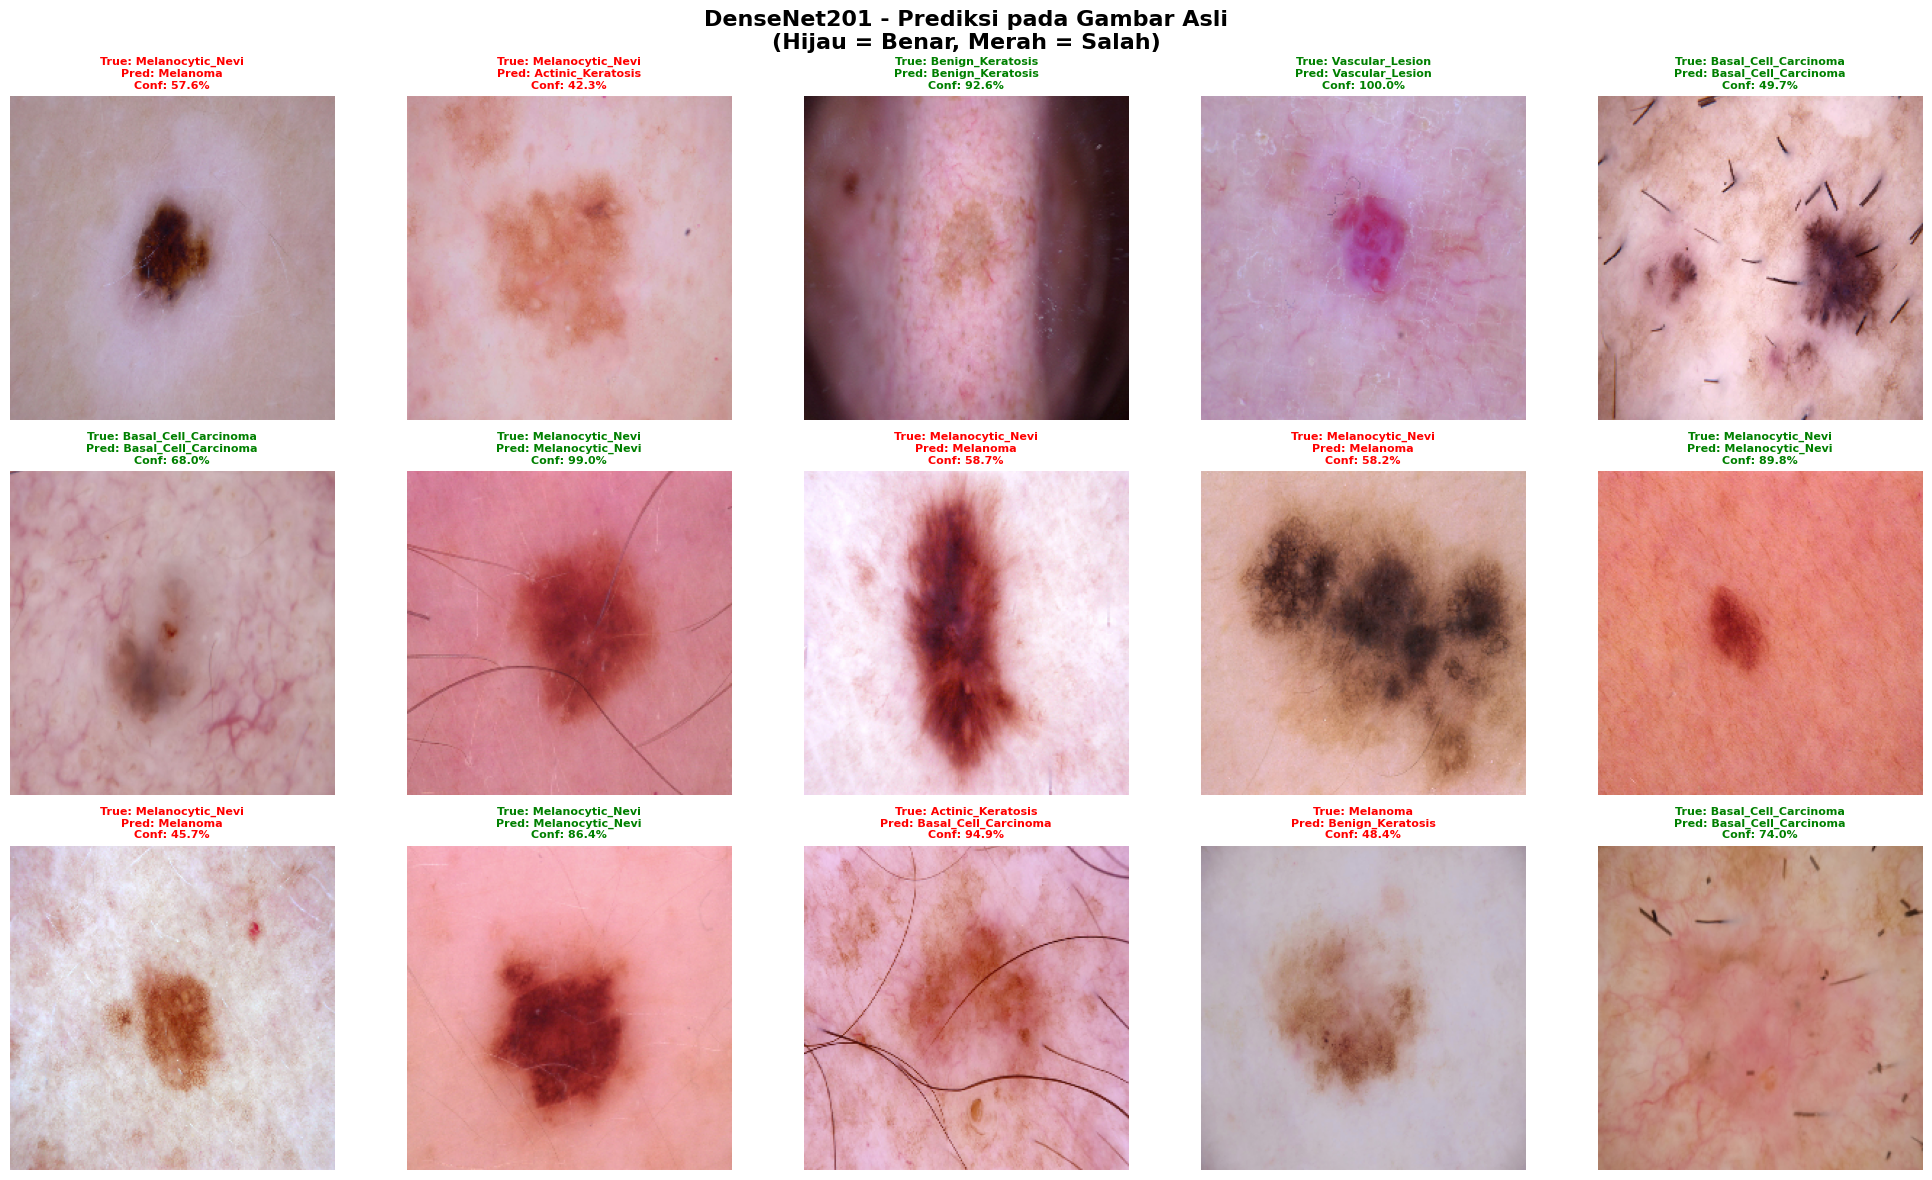

Saved!


In [12]:
# ============================================
# CELL 11: VISUALISASI PREDIKSI PADA GAMBAR ASLI
# ============================================
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Ambil 15 gambar random dari test
all_files = []
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith('.jpg')]
    all_files.extend([(f, cls) for f in files])

samples = random.sample(all_files, 15)

for i, (filepath, true_label) in enumerate(samples):
    row, col = i // 5, i % 5

    # Load & predict
    img = load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_display = img_array / 255.0

    # DenseNet predict
    img_dense = dense_preprocess(img_array.copy())
    pred = model_dense.predict(np.expand_dims(img_dense, 0), verbose=0)
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    # Display
    axes[row, col].imshow(img_display)
    correct = pred_label == true_label
    color = 'green' if correct else 'red'
    axes[row, col].set_title(
        f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
        fontsize=8, color=color, fontweight='bold'
    )
    axes[row, col].axis('off')

plt.suptitle('DenseNet201 - Prediksi pada Gambar Asli\n(Hijau = Benar, Merah = Salah)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Data Projek Big Data/prediction_samples.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved!")